<a href="https://colab.research.google.com/github/SANGRAMLEMBE/100_days_of_ML/blob/main/Day37_Handling_Missing_Categorical_Data/Frequent_Value_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd

In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('train.csv', usecols=['GarageQual','FireplaceQu','SalePrice'])

In [30]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [31]:
df.isnull().mean()*100

# here we have around 50% values are missing and 5% values are missing in 2 column section

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


Text(0.5, 1.0, 'GarageQual')

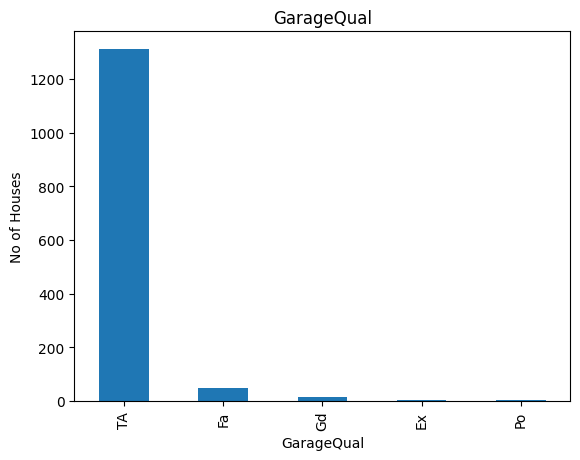

In [32]:
df['GarageQual'].value_counts().sort_values(ascending= False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('No of Houses')
plt.title('GarageQual')

In [33]:
df['GarageQual'].mode()

,GarageQual
0,TA


Text(0, 0.5, 'Density')

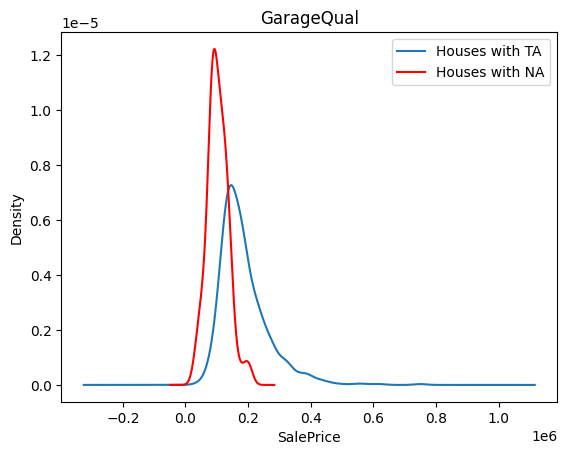

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA'] ['SalePrice'].plot(kind = 'kde', ax = ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind= 'kde', ax = ax, color = 'red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc = 'best')

plt.title('GarageQual')
plt.xlabel('SalePrice')
plt.ylabel('Density')

In [35]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [36]:
df['GarageQual'].fillna('TA', inplace = True)

/tmp/ipykernel_4177/2652256314.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace = True)


<Axes: xlabel='GarageQual'>

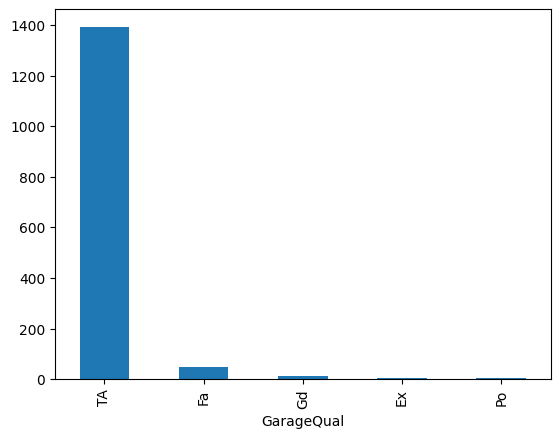

In [37]:
df['GarageQual'].value_counts().plot(kind = 'bar')

Text(0, 0.5, 'Density')

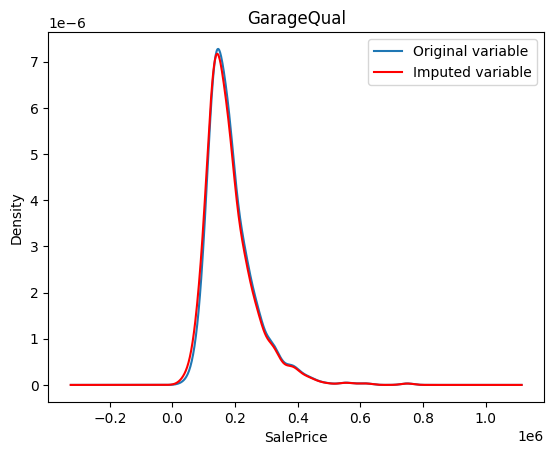

In [38]:
fig = plt.figure()
ax= fig.add_subplot(111)

temp.plot(kind= 'kde', ax = ax)

# distribution of variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind= 'kde', ax = ax, color = 'red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc = 'best')

plt.title('GarageQual')
plt.xlabel('SalePrice')
plt.ylabel('Density')

<Axes: xlabel='FireplaceQu'>

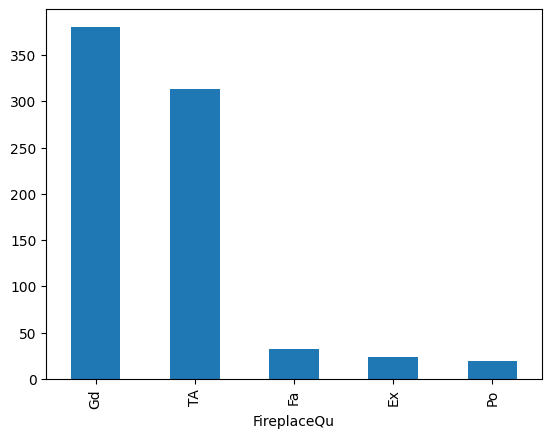

In [39]:
df['FireplaceQu'].value_counts().plot(kind = 'bar')

# when we are replacing with most frequent, there must be huge differnce between 2 classes which we don't have here

In [40]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


Text(0.5, 1.0, 'FireplaceQu')

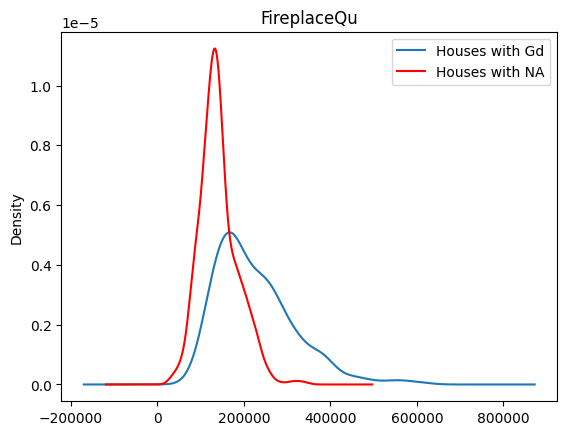

In [41]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [42]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']


In [43]:
df['FireplaceQu'].fillna('Gd', inplace=True)



/tmp/ipykernel_4177/1136674974.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

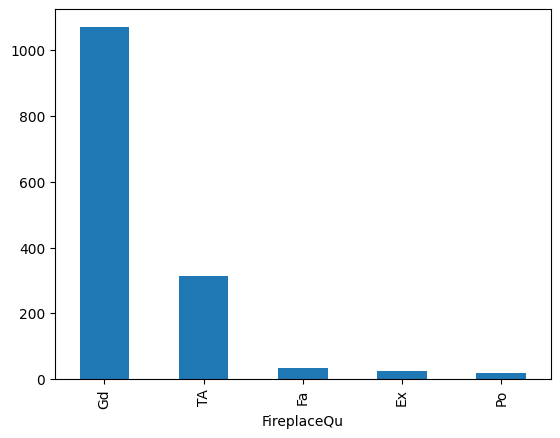

In [44]:
df['FireplaceQu'].value_counts().plot(kind='bar')


Text(0.5, 1.0, 'FireplaceQu')

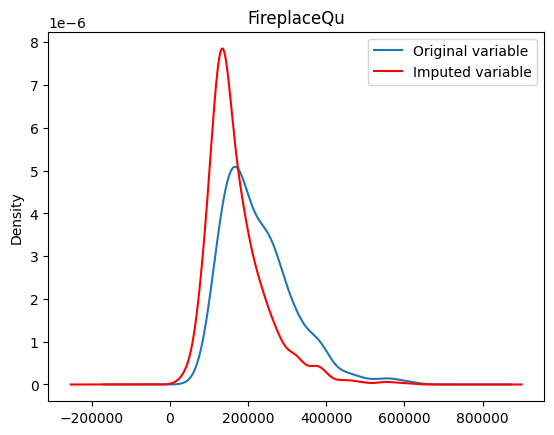

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop(labels=['SalePrice'], axis=1),
                                                    df['SalePrice'],
                                                    test_size=0.3,
                                                    random_state=0)

In [47]:
from sklearn.impute import SimpleImputer

In [48]:
imputer = SimpleImputer(strategy='most_frequent')

In [49]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [50]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)